# 22 logreg Optuna

## Import

In [1]:
import time

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LogisticRegression

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import joblib

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [3]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [4]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]
x_full, y_full = df_raw[feat_cols], df_raw["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)],
        "full": [len(df_raw), len(x_full), len(y_full)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
full     [595212, 595212, 595212]
dtype: object

## Hilfsvariablen

In [5]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

In [6]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

## Learning Curve Splits

In [7]:
setsizes = [0.1, 0.25, 0.5, 0.75, 1.0]

rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(x_train))

idx_lc_10 = perm[:int(len(x_train) * 0.1)]
idx_lc_25 = perm[:int(len(x_train) * 0.25)]
idx_lc_50 = perm[:int(len(x_train) * 0.5)]
idx_lc_75 = perm[:int(len(x_train) * 0.75)]
idx_lc_100 = perm

idx_lc = {
    0.1: idx_lc_10,
    0.25: idx_lc_25,
    0.5: idx_lc_50,
    0.75: idx_lc_75,
    1.0: idx_lc_100
}


In [8]:
pd.DataFrame([
    {
        "anteil": f,
        "train_size": len(idx_lc[f]),
        "n_pos": int(y_train.iloc[idx_lc[f]].sum()),
        "pos_rate": y_train.iloc[idx_lc[f]].mean()
    }
    for f in setsizes
])

,anteil,train_size,n_pos,pos_rate
0,0.10,47616,1725,0.036227
1,0.25,119042,4304,0.036155
2,0.50,238084,8608,0.036155
3,0.75,357126,13035,0.036500
4,1.00,476168,17356,0.036449


## Preproc Logreg

In [9]:
x_train_lr = x_train
x_val_lr = x_val
x_test_lr = x_test
x_full_lr = x_full

pd.Series(
    {
        "train": [len(x_train), len(x_train_lr)],
        "val": [len(x_val), len(x_val_lr)],
        "test": [len(x_test), len(x_test_lr)],
        "full": [len(x_full), len(x_full_lr)]
    }
)

train    [476168, 476168]
val        [59522, 59522]
test       [59522, 59522]
full     [595212, 595212]
dtype: object

In [10]:
prep_calc = make_column_transformer(
    (
    make_pipeline(
        (SimpleImputer(strategy="median", add_indicator=True)),
        (StandardScaler()),
        ), num_cols
    ),
    (
    OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        drop="first"
        ), low_kard_cols
    ),
    (
        make_pipeline(
            (TargetEncoder(
                cv=5,
                shuffle=True,
                smooth=50.0,
                random_state=RANDOM_STATE
                )
            ),
            (
                StandardScaler()
            )
        ), high_kard_cols
    ),
    (
        "passthrough", bin_cols
    ),
    remainder="drop"
)

In [11]:
prep_no_calc = make_column_transformer(
    (
    make_pipeline(
        (SimpleImputer(strategy="median", add_indicator=True)),
        (StandardScaler()),
        ), num_cols_no_calc
    ),
    (
    OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        drop="first"
        ), low_kard_cols
    ),
    (
        make_pipeline(
            (TargetEncoder(
                cv=5,
                shuffle=True,
                smooth=50.0,
                random_state=RANDOM_STATE
                )
            ),
            (
                StandardScaler()
            )
        ), high_kard_cols
    ),
    (
        "passthrough", bin_cols_no_calc
    ),
    remainder="drop"
)

In [12]:
prep_check = clone(prep_calc).fit(x_train_lr, y_train)
prep_check_no_calc = clone(prep_no_calc).fit(x_train_lr, y_train)

pd.Series({
    "features_calc": len(prep_check.get_feature_names_out()),
    "features_no_calc": len(prep_check_no_calc.get_feature_names_out())
})

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


features_calc       114
features_no_calc     94
dtype: int64

## Learning Curves

In [13]:
lc_results = []

for trainset in setsizes:
    idx_sub = idx_lc[trainset]
    x_sub, y_sub = x_train_lr.iloc[idx_sub], y_train.iloc[idx_sub]

    model = Pipeline([
        ("prep", clone(prep_no_calc)),
        ("clf", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000,
            tol=1e-4,
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            class_weight=None
        ))
    ])

    start = time.time()
    model.fit(x_sub, y_sub)
    fit_time = time.time() - start

    lc_results.append({
        "train_size": len(idx_sub),
        "anteil": trainset,
        "n_iter": model["clf"].n_iter_[0],
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_lr)[:, 1]),
        "fit_time": fit_time
    })

df_lc_results = pd.DataFrame(lc_results)
df_lc_results

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` ar

,train_size,anteil,n_iter,auc_train,auc_val,fit_time
0,47616,0.10,51,0.653224,0.605296,0.367233
1,119042,0.25,49,0.632941,0.612846,1.003348
2,238084,0.50,44,0.632122,0.616081,2.007006
3,357126,0.75,43,0.633373,0.617314,3.031839
4,476168,1.00,49,0.634837,0.618211,4.950768


Text(0.5, 1.0, 'LogReg Learning Curve (l2, C=1.0, ohne Calc)')

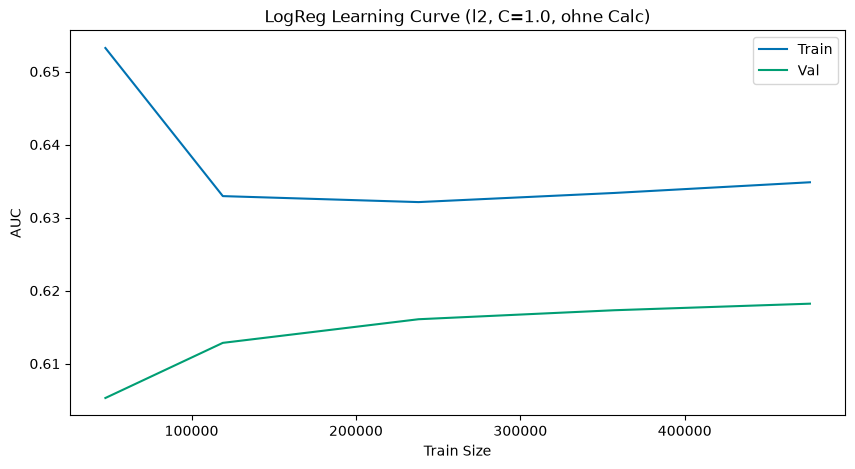

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_lc_results["train_size"], df_lc_results["auc_train"], label="Train")
ax.plot(df_lc_results["train_size"], df_lc_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("LogReg Learning Curve (l2, C=1.0, ohne Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (l2, C=1.0, ohne Calc)')

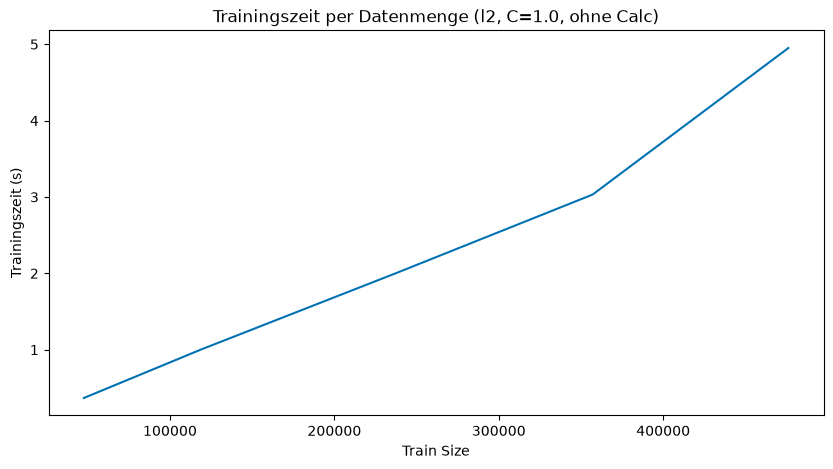

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_lc_results["train_size"], df_lc_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (l2, C=1.0, ohne Calc)")

## Optuna Hilfe

Suchräume:

|Parameter|Bereich|
|---|---|
|C|1e-4 bis 1e6 (log)|
|solver|lbfgs / saga|
|l1_ratio|0.0 - 0.1|
|class_weight|None / Balanced|

In [16]:
fixed_params_lr = {
    "random_state": RANDOM_STATE,
    "max_iter": 500,
    "tol": 1e-4,
    "fit_intercept": True
}

In [17]:
def suchraum_params(trial):
    """Suchraum definition"""
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e6, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0, step=0.1),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }

    if params["l1_ratio"] == 0.0:
        params["solver"] = "lbfgs"
    else:
        params["solver"] = "saga"

    return params

In [18]:
def params_aus_study(best_params):
    """best_params der Study für Konstruktr"""
    params = dict(best_params)

    if params["l1_ratio"] == 0.0:
        params["solver"] = "lbfgs"
    else:
        params["solver"] = "saga"

    return params

## Mit Calc

In [19]:
def objective_lr_calc(trial):

    modell = make_pipeline(
        (
            clone(prep_calc)
        ),
        (
            LogisticRegression(
                **fixed_params_lr,
                **suchraum_params(trial)
            )
        )
    )

    modell.fit(x_train_lr, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_lr)[:, 1])

In [20]:
study_lr_calc = optuna.create_study(
    study_name="logreg_calc",
    storage="sqlite:///logreg_opti.db",
    load_if_exists=True,
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=50)
)

[I 2026-08-21 00:45:11,281] A new study created in RDB with name: logreg_calc


In [21]:
study_lr_calc.optimize(
    objective_lr_calc,
    n_trials=50,
    timeout= 4*60*60,
    catch=(Exception, )
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-08-21 00:50:30,598] Trial 0 finished with value: 0.6162534294883907 and parameters: {'C': 0.5564180225431369, 'l1_ratio': 1.0, 'class_weight': None}. Best is trial 0 with value: 0.6162534294883907.
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validati

In [22]:
pd.Series({
    "best auc val": study_lr_calc.best_value,
    "best gini": 2 * study_lr_calc.best_value - 1,
    "trials": len(study_lr_calc.trials),
    "pruned": len([t for t in study_lr_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_lr_calc.trials if t.state.name == "FAIL"]),
    "best params": study_lr_calc.best_params
})

best auc val                                             0.618268
best gini                                                0.236536
trials                                                         50
pruned                                                          0
fail                                                            0
best params     {'C': 0.008758757178278604, 'l1_ratio': 0.9, '...
dtype: object

In [23]:
study_lr_calc.best_params

{'C': 0.008758757178278604, 'l1_ratio': 0.9, 'class_weight': 'balanced'}

## Ohne Calc

In [24]:
def objective_lr_no_calc(trial):

    modell = make_pipeline(
        (
            clone(prep_no_calc)
        ),
        (
            LogisticRegression(
                **fixed_params_lr,
                **suchraum_params(trial)
            )
        )
    )

    modell.fit(x_train_lr, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_lr)[:, 1])

In [25]:
study_lr_no_calc = optuna.create_study(
    study_name="logreg_no_calc",
    storage="sqlite:///logreg_opti.db",
    load_if_exists=True,
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=50)
)

[I 2026-08-21 04:45:23,204] A new study created in RDB with name: logreg_no_calc


In [26]:
study_lr_no_calc.optimize(
    objective_lr_no_calc,
    n_trials=50,
    timeout= 4*60*60,
    catch=(Exception, )
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-08-21 04:50:04,423] Trial 0 finished with value: 0.6167245921312479 and parameters: {'C': 0.5564180225431369, 'l1_ratio': 1.0, 'class_weight': None}. Best is trial 0 with value: 0.6167245921312479.
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validati

In [27]:
pd.Series({
    "best auc val": study_lr_no_calc.best_value,
    "best gini": 2 * study_lr_no_calc.best_value - 1,
    "trials": len(study_lr_no_calc.trials),
    "pruned": len([t for t in study_lr_no_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_lr_no_calc.trials if t.state.name == "FAIL"]),
    "best params": study_lr_no_calc.best_params
})

best auc val                                             0.618582
best gini                                                0.237165
trials                                                         50
pruned                                                          0
fail                                                            0
best params     {'C': 0.007257724617055526, 'l1_ratio': 0.5, '...
dtype: object

In [28]:
study_lr_no_calc.best_params

{'C': 0.007257724617055526, 'l1_ratio': 0.5, 'class_weight': 'balanced'}

## Ohne Calc auf 25%

In [29]:
x_train_sub = x_train_lr.iloc[idx_lc_25]
y_train_sub = y_train.iloc[idx_lc_25]

In [30]:
def objective_lr_no_calc_sub(trial):

    modell = make_pipeline(
        (
            clone(prep_no_calc)
        ),
        (
            LogisticRegression(
                **fixed_params_lr,
                **suchraum_params(trial)
            )
        )
    )

    modell.fit(x_train_sub, y_train_sub)

    return roc_auc_score(y_val, modell.predict_proba(x_val_lr)[:, 1])

In [31]:
study_lr_no_calc_sub = optuna.create_study(
    study_name="logreg_no_calc_sub",
    storage="sqlite:///logreg_opti.db",
    load_if_exists=True,
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=50)
)

[I 2026-08-21 07:44:48,824] A new study created in RDB with name: logreg_no_calc_sub


In [32]:
study_lr_no_calc_sub.optimize(
    objective_lr_no_calc_sub,
    n_trials=50,
    timeout= 4*60*60,
    catch=(Exception, )
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-08-21 07:45:49,416] Trial 0 finished with value: 0.6105041471629392 and parameters: {'C': 0.5564180225431369, 'l1_ratio': 1.0, 'class_weight': None}. Best is trial 0 with value: 0.6105041471629392.
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validati

In [33]:
pd.Series({
    "best auc val": study_lr_no_calc_sub.best_value,
    "best gini": 2 * study_lr_no_calc_sub.best_value - 1,
    "trials": len(study_lr_no_calc_sub.trials),
    "pruned": len([t for t in study_lr_no_calc_sub.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_lr_no_calc_sub.trials if t.state.name == "FAIL"]),
    "best params": study_lr_no_calc_sub.best_params
})

best auc val                                             0.614304
best gini                                                0.228608
trials                                                         50
pruned                                                          0
fail                                                            0
best params     {'C': 0.029135585913319124, 'l1_ratio': 0.8, '...
dtype: object

In [34]:
study_lr_no_calc_sub.best_params

{'C': 0.029135585913319124, 'l1_ratio': 0.8, 'class_weight': 'balanced'}

## Load Study

In [35]:
study_lr_calc_loaded = optuna.load_study(
    study_name = "logreg_calc",
    storage = "sqlite:///logreg_opti.db"
)

study_lr_no_calc_loaded = optuna.load_study(
    study_name = "logreg_no_calc",
    storage = "sqlite:///logreg_opti.db"
)

study_lr_no_calc_sub_loaded = optuna.load_study(
    study_name = "logreg_no_calc_sub",
    storage = "sqlite:///logreg_opti.db"
)

## Best Params again

In [36]:
study_lr_calc_loaded.best_params

{'C': 0.008758757178278604, 'l1_ratio': 0.9, 'class_weight': 'balanced'}

In [37]:
study_lr_no_calc_loaded.best_params

{'C': 0.007257724617055526, 'l1_ratio': 0.5, 'class_weight': 'balanced'}

In [38]:
study_lr_no_calc_sub_loaded.best_params

{'C': 0.029135585913319124, 'l1_ratio': 0.8, 'class_weight': 'balanced'}

## 100% Train

In [39]:
results = []
train_times = {}

In [40]:
name = "L_lr_opt_01"

L_lr_opt_01 = make_pipeline(
    (
        clone(prep_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_calc_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_01.fit(
    x_train_lr, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_01, x_train_lr, y_train, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [41]:
name = "L_lr_opt_02"

L_lr_opt_02 = make_pipeline(
    (
        clone(prep_no_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_no_calc_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_02.fit(
    x_train_lr, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_02, x_train_lr, y_train, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [42]:
name = "L_lr_opt_03"

L_lr_opt_03 = make_pipeline(
    (
        clone(prep_no_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_no_calc_sub_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_03.fit(
    x_train_lr, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_03, x_train_lr, y_train, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [43]:
name = "L_lr_opt_04"

L_lr_opt_04 = make_pipeline(
    (
        clone(prep_no_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_no_calc_sub_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_04.fit(
    x_train_sub, y_train_sub
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_04, x_train_sub, y_train_sub, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [44]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_lr_opt_01,0.634603,0.618268,0.236536,0.016335,None,282.010512
1,L_lr_opt_02,0.634689,0.618582,0.237165,0.016107,None,230.930150
2,L_lr_opt_03,0.635121,0.618241,0.236481,0.016880,None,281.836698
3,L_lr_opt_04,0.632634,0.614304,0.228608,0.018330,None,58.583413


## Save Models

In [45]:
Modelle = [
    (L_lr_opt_01, "L_lr_opt_01"),
    (L_lr_opt_02, "L_lr_opt_02"),
    (L_lr_opt_03, "L_lr_opt_03"),
    (L_lr_opt_04, "L_lr_opt_04")
]

for modell, name in Modelle:
    joblib.dump(modell, f"{name}.joblib")

## Notizen
- Ich richte mich beim target encoder nach J_D
- missing kategorie
- learning curves wegen letzten optimierungsversuchen
- scaler nach target encoder
- bei der trainingsgröße sollte eine normale optuna optimierung gehen. interessant wäre wahrscheinlich 25%, aber ich möchte lieber ertsmal 100% probieren.
- simpleres grid
- trainiere am ende 03 sub modell auf full und 04 sub modell auf sub
- war eine dumme idee n_iter so hoch zu setzen, nicht konvergierte fits dauern extrem lang. Muss die suche nochmal abbrechen und mit 500 starten. der effizienz wegen.